In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

Import data

In [2]:
STN_DATA = xr.open_dataarray("../DATA/STN_DATA.nc")
ET_COM = xr.open_dataarray("../DATA/STN_COM.nc")
STS_DATA = xr.open_dataarray("../DATA/STN_STS.nc")

Separate PM from Estimates

In [3]:
ET_OBS = STN_DATA.loc[dict(Product="PM")]
ET_REMOTE = STN_DATA.drop_sel(Product="PM")
ET_LSA = STN_DATA.loc[dict(Product="LSA")]
ET_STS = STS_DATA  

Calculate Errors ( = Estimate - PM )

In [4]:
ERR_LSA = ET_LSA - ET_OBS
ERR_COM = ET_COM - ET_OBS
ERR_STS = ET_STS - ET_OBS 

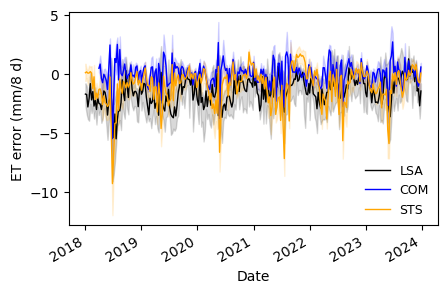

In [5]:
# Set up figure
fig, ax = plt.subplots(figsize=(4.5, 2.5))
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.labelpad': 2
})

# Calculate medians without quantile label
median_lsa = ERR_LSA.quantile(0.5, dim=["Station"])
median_com = ERR_COM.quantile(0.5, dim=["Station"])
median_sts = ERR_STS.quantile(0.5, dim=["Station"]) 

# Plot lines
ax.plot(median_lsa.datetime, median_lsa, label="LSA", color="black", linewidth=1)
ax.plot(median_com.datetime, median_com, label="COM", color="blue", linewidth=1)
ax.plot(median_sts.datetime, median_sts, label="STS", color="orange", linewidth=1) 

# Plot interquartile ranges
ax.fill_between(ERR_LSA.datetime, 
               ERR_LSA.quantile(0.25, dim=["Station"]),
               ERR_LSA.quantile(0.75, dim=["Station"]),
               color="black", alpha=0.15, label='_nolegend_')

ax.fill_between(ERR_COM.datetime, 
               ERR_COM.quantile(0.25, dim=["Station"]),
               ERR_COM.quantile(0.75, dim=["Station"]),
               color="blue", alpha=0.15, label='_nolegend_')

ax.fill_between(ERR_STS.datetime, 
               ERR_STS.quantile(0.25, dim=["Station"]),
               ERR_STS.quantile(0.75, dim=["Station"]),
               color="orange", alpha=0.15, label='_nolegend_')  

# Axis labels
ax.set_ylabel("ET error (mm/8 d)")
ax.set_xlabel("Date")

# Legend 
ax.legend(frameon=False, fontsize=9, loc='lower right', 
          bbox_to_anchor=(1.0, 0.0), borderaxespad=0.3)

# Date formatting
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
fig.autofmt_xdate()

# Adjust layout
plt.subplots_adjust(bottom=0.03, left=0.03, right=0.85) 

# Save figure
plt.savefig("ET4I_ET_ERR_TimeSeries.png", dpi=300, bbox_inches='tight')
plt.show()